# 🔍 Deep Dive Insight — Analisis Klaim Asuransi

Notebook ini menggali **insight bisnis lebih dalam** dari data klaim asuransi yang sudah di-enrich.
Meliputi: Medical Tourism, Cancer Cost Driver, Processing Efficiency, Seasonality, Lag Time,
Coverage Gap, Fraud Detection, dan Executive Summary.

---
## Phase 0: Setup & Data Quality Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette("husl")
COLORS = sns.color_palette("husl", 12)

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load data
df = pd.read_csv('dataset/Data_Klaim_Enriched.csv')
df_polis = pd.read_csv('dataset/Data_Polis.csv')

# Parse dates
date_cols = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['Tanggal Lahir'] = pd.to_datetime(df['Tanggal Lahir'], errors='coerce')
df['Tanggal Efektif Polis'] = pd.to_datetime(df['Tanggal Efektif Polis'], errors='coerce')

print(f"✅ Data loaded: {df.shape[0]:,} klaim, {df.shape[1]} kolom")
print(f"   Polis data: {df_polis.shape[0]:,} polis")
print(f"   Periode: {df['Tanggal Pasien Masuk RS'].min().date()} s/d {df['Tanggal Pasien Masuk RS'].max().date()}")

✅ Data loaded: 4,625 klaim, 28 kolom
   Polis data: 4,096 polis
   Periode: 2024-01-01 s/d 2025-07-31


### 0.1 Validasi Logika Tanggal

In [3]:
# Validasi LOS negatif
neg_los = df[df['LOS'] < 0]
print(f"⚠️  Klaim dengan LOS negatif: {len(neg_los)}")
if len(neg_los) > 0:
    display(neg_los[['Claim ID','Tanggal Pasien Masuk RS','Tanggal Pasien Keluar RS','LOS']].head(10))

# Validasi Tgl Bayar < Tgl Pulang (pembayaran sebelum pulang → wajar untuk cashless)
bayar_before_pulang = df[df['Tanggal Pembayaran Klaim'] < df['Tanggal Pasien Keluar RS']]
print(f"\n📋 Klaim dengan Tgl Bayar < Tgl Pulang: {len(bayar_before_pulang)} ({len(bayar_before_pulang)/len(df)*100:.1f}%)")
print("   (Wajar untuk klaim Cashless yang diproses selama rawat inap)")

# Breakdown per tipe
if len(bayar_before_pulang) > 0:
    print(bayar_before_pulang['Reimburse/Cashless'].value_counts().to_string())

⚠️  Klaim dengan LOS negatif: 0

📋 Klaim dengan Tgl Bayar < Tgl Pulang: 0 (0.0%)
   (Wajar untuk klaim Cashless yang diproses selama rawat inap)


### 0.2 Standarisasi Lokasi RS & Feature Engineering

In [4]:
# Cek inkonsistensi Lokasi RS
print("📍 Lokasi RS unik:")
print(df['Lokasi RS'].value_counts().to_string())

# Klasifikasi domestik vs luar negeri
luar_negeri = ['Singapore', 'Malaysia', 'Hong Kong', 'Japan', 'Taiwan', 'Tiongkok', 'Others', 'Overseas']
df['Is_Overseas'] = df['Lokasi RS'].isin(luar_negeri)
df['Region'] = df['Lokasi RS'].apply(lambda x: 'Luar Negeri' if x in luar_negeri else 'Indonesia')

print(f"\n🌏 Domestik: {(~df['Is_Overseas']).sum():,} | Luar Negeri: {df['Is_Overseas'].sum():,}")

📍 Lokasi RS unik:
Lokasi RS
Indonesia    3100
Singapore    1019
Malaysia      456
Overseas       28
Others          6
Taiwan          5
Hong Kong       1
Japan           1
Tiongkok        1
Australia       1

🌏 Domestik: 3,108 | Luar Negeri: 1,517


💰 Klaim Catastrophic (>500 Juta): 76 klaim (1.6%)
   Total nominal catastrophic: Rp 63.5 Miliar (24.9% dari total)


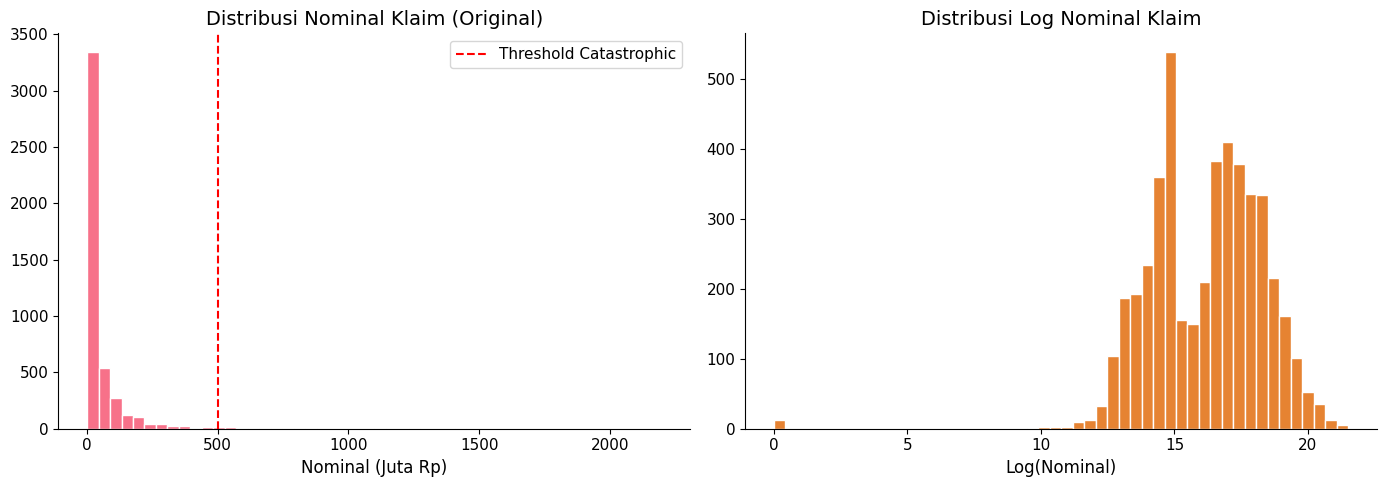

In [5]:
# Log-Transform nominal
df['Log_Nominal'] = np.log1p(df['Nominal Klaim Yang Disetujui'].fillna(0))
df['Log_Biaya_RS'] = np.log1p(df['Nominal Biaya RS Yang Terjadi'].fillna(0))

# Pisahkan Regular vs Catastrophic
CATASTROPHIC_THRESHOLD = 500_000_000
df['Is_Catastrophic'] = df['Nominal Klaim Yang Disetujui'] > CATASTROPHIC_THRESHOLD
df['Claim_Category'] = df['Is_Catastrophic'].map({True: 'Catastrophic (>500M)', False: 'Regular'})

n_cat = df['Is_Catastrophic'].sum()
total_cat = df.loc[df['Is_Catastrophic'], 'Nominal Klaim Yang Disetujui'].sum()
total_all = df['Nominal Klaim Yang Disetujui'].sum()

print(f"💰 Klaim Catastrophic (>500 Juta): {n_cat} klaim ({n_cat/len(df)*100:.1f}%)")
print(f"   Total nominal catastrophic: Rp {total_cat/1e9:.1f} Miliar ({total_cat/total_all*100:.1f}% dari total)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Nominal Klaim Yang Disetujui'].dropna()/1e6, bins=50, color=COLORS[0], edgecolor='white')
axes[0].set_title('Distribusi Nominal Klaim (Original)')
axes[0].set_xlabel('Nominal (Juta Rp)')
axes[0].axvline(500, color='red', linestyle='--', label='Threshold Catastrophic')
axes[0].legend()

axes[1].hist(df['Log_Nominal'].dropna(), bins=50, color=COLORS[1], edgecolor='white')
axes[1].set_title('Distribusi Log Nominal Klaim')
axes[1].set_xlabel('Log(Nominal)')
plt.tight_layout()
plt.show()

---
## Phase 1: Medical Tourism Deep Dive

### 1.1 Profil Nasabah yang Berobat ke Luar Negeri

In [6]:
overseas = df[df['Is_Overseas']].copy()
domestic = df[~df['Is_Overseas']].copy()

print(f"🌏 Total klaim luar negeri: {len(overseas):,} ({len(overseas)/len(df)*100:.1f}%)")
print(f"   Total nominal: Rp {overseas['Nominal Klaim Yang Disetujui'].sum()/1e9:.1f} Miliar")
print(f"\n📊 Breakdown per negara:")
print(overseas['Lokasi RS'].value_counts().to_string())

🌏 Total klaim luar negeri: 1,517 (32.8%)
   Total nominal: Rp 149.8 Miliar

📊 Breakdown per negara:
Lokasi RS
Singapore    1019
Malaysia      456
Overseas       28
Others          6
Taiwan          5
Hong Kong       1
Japan           1
Tiongkok        1


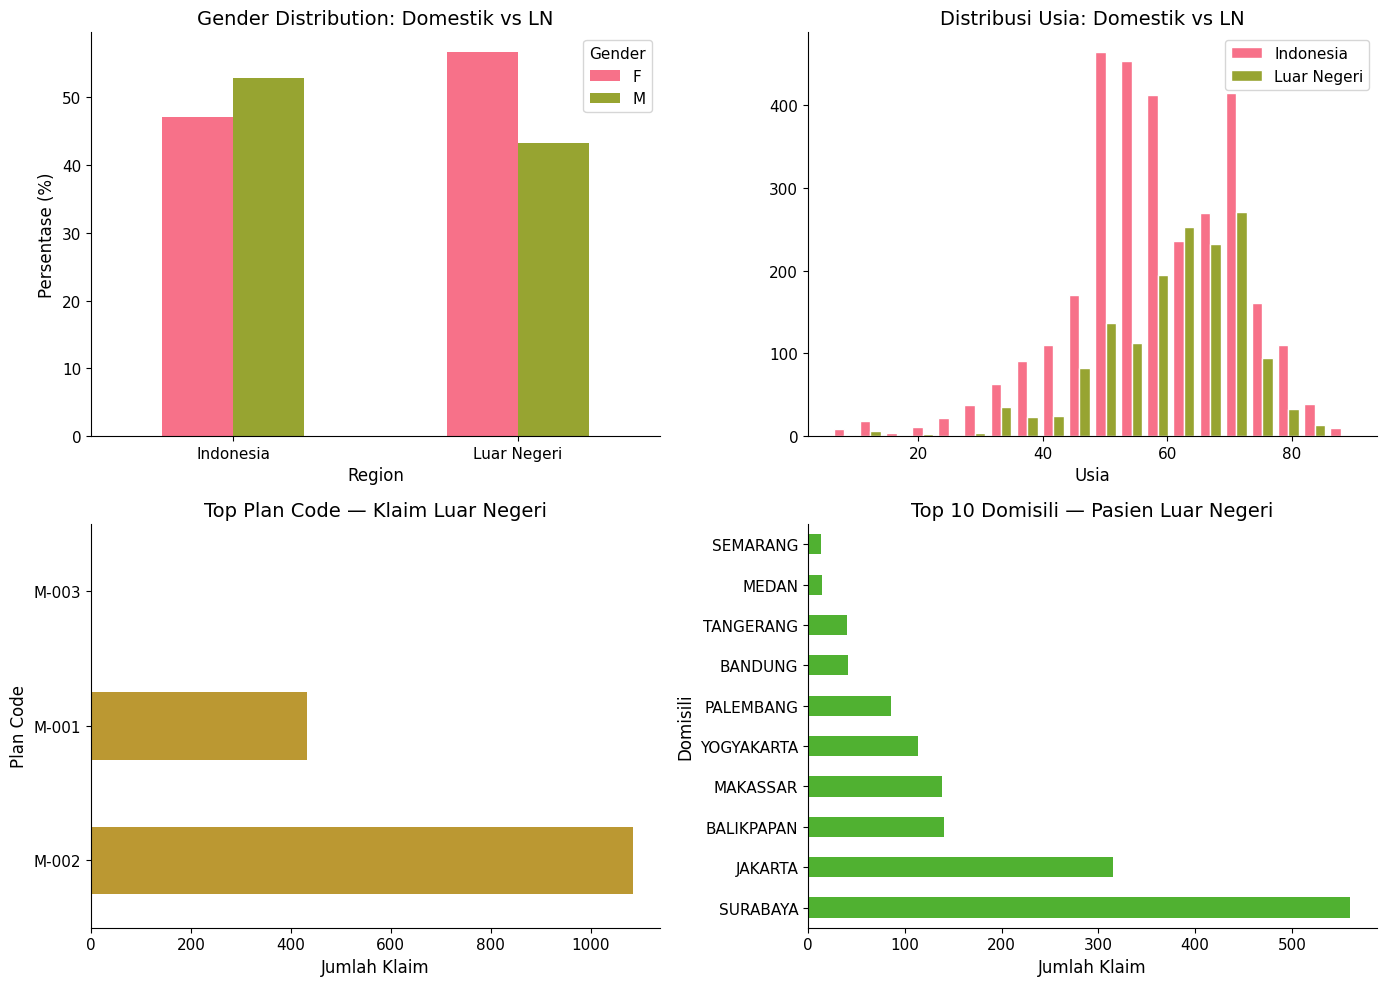

In [7]:
# Profil demografi overseas vs domestic
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_data = pd.crosstab(df['Region'], df['Gender'], normalize='index') * 100
gender_data.plot(kind='bar', ax=axes[0,0], color=[COLORS[0], COLORS[3]])
axes[0,0].set_title('Gender Distribution: Domestik vs LN')
axes[0,0].set_ylabel('Persentase (%)')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].legend(title='Gender')

# Usia
axes[0,1].hist([domestic['Usia'].dropna(), overseas['Usia'].dropna()],
               bins=20, label=['Indonesia', 'Luar Negeri'], color=[COLORS[0], COLORS[3]], edgecolor='white')
axes[0,1].set_title('Distribusi Usia: Domestik vs LN')
axes[0,1].set_xlabel('Usia')
axes[0,1].legend()

# Plan Code
plan_overseas = overseas['Plan Code'].value_counts().head(8)
plan_overseas.plot(kind='barh', ax=axes[1,0], color=COLORS[2])
axes[1,0].set_title('Top Plan Code — Klaim Luar Negeri')
axes[1,0].set_xlabel('Jumlah Klaim')

# Domisili
dom_overseas = overseas['Domisili'].value_counts().head(10)
dom_overseas.plot(kind='barh', ax=axes[1,1], color=COLORS[4])
axes[1,1].set_title('Top 10 Domisili — Pasien Luar Negeri')
axes[1,1].set_xlabel('Jumlah Klaim')

plt.tight_layout()
plt.show()

### 1.2 Perbandingan Biaya per Diagnosis: Indonesia vs Luar Negeri

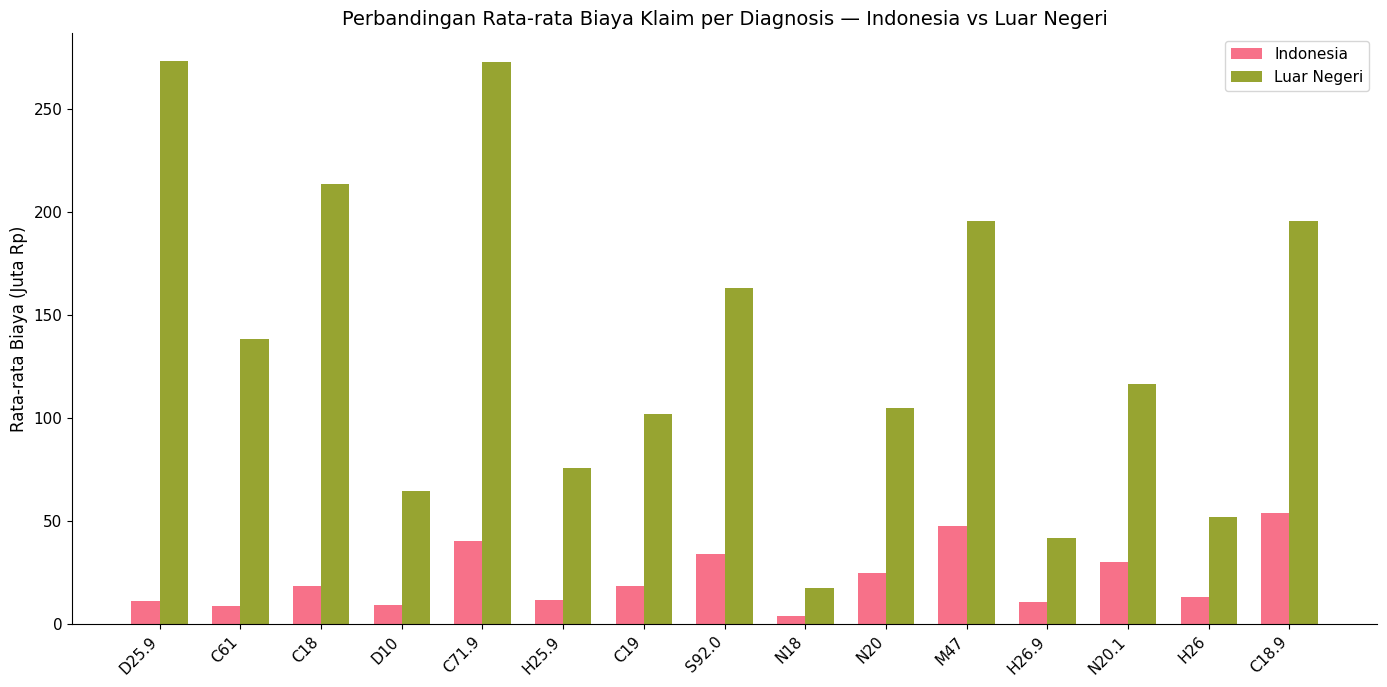


📊 Rasio Biaya Luar Negeri / Indonesia:
   D25.9: 24.4x lebih mahal di LN
   C61: 15.3x lebih mahal di LN
   C18: 11.5x lebih mahal di LN
   D10: 6.8x lebih mahal di LN
   C71.9: 6.7x lebih mahal di LN
   H25.9: 6.4x lebih mahal di LN
   C19: 5.4x lebih mahal di LN
   S92.0: 4.8x lebih mahal di LN
   N18: 4.6x lebih mahal di LN
   N20: 4.2x lebih mahal di LN
   M47: 4.1x lebih mahal di LN
   H26.9: 3.9x lebih mahal di LN
   N20.1: 3.9x lebih mahal di LN
   H26: 3.9x lebih mahal di LN
   C18.9: 3.6x lebih mahal di LN


In [9]:
# Top diagnosis yang ada di kedua region
diag_both = df.groupby(['ICD Diagnosis', 'Region'])['Nominal Klaim Yang Disetujui'].agg(['mean','count'])
diag_both = diag_both.reset_index()
diag_pivot = diag_both.pivot(index='ICD Diagnosis', columns='Region', values='mean')
diag_count = diag_both.pivot(index='ICD Diagnosis', columns='Region', values='count')

# Filter diagnosis yang ada di kedua region dengan min 3 klaim
mask = (diag_count['Indonesia'].fillna(0) >= 3) & (diag_count['Luar Negeri'].fillna(0) >= 3)
diag_compare = diag_pivot[mask].dropna().copy()
diag_compare['Rasio_LN_vs_ID'] = diag_compare['Luar Negeri'] / diag_compare['Indonesia']
diag_compare = diag_compare.sort_values('Rasio_LN_vs_ID', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(diag_compare))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], diag_compare['Indonesia']/1e6, width, label='Indonesia', color=COLORS[0])
bars2 = ax.bar([i + width/2 for i in x], diag_compare['Luar Negeri']/1e6, width, label='Luar Negeri', color=COLORS[3])
ax.set_xticks(x)
ax.set_xticklabels(diag_compare.index, rotation=45, ha='right')
ax.set_ylabel('Rata-rata Biaya (Juta Rp)')
ax.set_title('Perbandingan Rata-rata Biaya Klaim per Diagnosis — Indonesia vs Luar Negeri')
ax.legend()
plt.tight_layout()
plt.show()

print("\n📊 Rasio Biaya Luar Negeri / Indonesia:")
for diag, row in diag_compare.iterrows():
    print(f"   {diag}: {row['Rasio_LN_vs_ID']:.1f}x lebih mahal di LN")

### 1.3 Diagnosis yang "Harus" ke Luar Negeri vs Bisa di Indonesia

In [ ]:
# Diagnosis yang mayoritas (>70%) dirawat di luar negeri
diag_region = df.groupby('ICD Diagnosis').agg(
    total=('Claim ID', 'count'),
    overseas_count=('Is_Overseas', 'sum'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()
diag_region['overseas_pct'] = diag_region['overseas_count'] / diag_region['total'] * 100

# Filter min 5 klaim
diag_region_sig = diag_region[diag_region['total'] >= 5].sort_values('overseas_pct', ascending=False)

print("🏥 Diagnosis yang MAYORITAS (>70%) dirawat di Luar Negeri:")
harus_ln = diag_region_sig[diag_region_sig['overseas_pct'] > 70]
if len(harus_ln) > 0:
    for _, row in harus_ln.head(10).iterrows():
        desc = df[df['ICD Diagnosis'] == row['ICD Diagnosis']]['ICD Description'].iloc[0]
        print(f"   {row['ICD Diagnosis']} ({desc}): {row['overseas_pct']:.0f}% LN, avg Rp {row['avg_nominal']/1e6:.0f}jt")
else:
    print("   Tidak ada diagnosis dengan >70% klaim di LN (dengan min 5 klaim)")

print("\n🏥 Diagnosis yang BISA ditangani di Indonesia (>80% domestik) tapi tetap ada yang ke LN:")
bisa_id = diag_region_sig[(diag_region_sig['overseas_pct'] > 0) & (diag_region_sig['overseas_pct'] <= 20)]
for _, row in bisa_id.head(10).iterrows():
    desc = df[df['ICD Diagnosis'] == row['ICD Diagnosis']]['ICD Description'].iloc[0]
    print(f"   {row['ICD Diagnosis']} ({desc}): {row['overseas_pct']:.0f}% LN, avg Rp {row['avg_nominal']/1e6:.0f}jt")

🏥 Diagnosis yang MAYORITAS (>70%) dirawat di Luar Negeri:
   C25 (MALIGNANT NEOPLASM OF PANCREAS): 100% LN, avg Rp 86jt
   C25.9 (Pancreas, unspecified): 100% LN, avg Rp 203jt
   C49.9 (Connective and soft tissue,unspecified): 100% LN, avg Rp 62jt
   C55 (Malignant neoplasm of uterus, part unspecified): 100% LN, avg Rp 33jt
   C56 (Malignant neoplasm of ovari): 100% LN, avg Rp 29jt
   D24 (Benign neoplasm of breast): 100% LN, avg Rp 39jt
   C90 (MULTIPLE MYELOMA AND MALIGNANT PLASMA CELL NEOPLASMA): 100% LN, avg Rp 60jt
   C90.0 (Multiple myeloma): 100% LN, avg Rp 101jt
   C82.9 (Follicular non-Hodgkin's lymphoma, unspecified): 100% LN, avg Rp 34jt
   C65 (MALIGNANT NEOPLASM OF RENAL PELVIS): 100% LN, avg Rp 98jt

🏥 Diagnosis yang BISA ditangani di Indonesia (>80% domestik) tapi tetap ada yang ke LN:
   S82.0 (FRACTURE OF PATELLA): 20% LN, avg Rp 22jt Region         Indonesia  Luar Negeri
ICD Diagnosis                        
A01                  4.0          NaN
A01.0                4

### 1.4 Heatmap: Domisili × Lokasi RS

In [ ]:
heatmap_data = pd.crosstab(df['Domisili'], df['Lokasi RS'])
# Filter top domisili
top_dom = df['Domisili'].value_counts().head(15).index
heatmap_filtered = heatmap_data.loc[heatmap_data.index.isin(top_dom)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_filtered, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmap: Domisili × Lokasi RS (Top 15 Domisili)')
ax.set_ylabel('Domisili Nasabah')
ax.set_xlabel('Lokasi RS')
plt.tight_layout()
plt.show()

print("\n💡 Insight: Kota mana yang paling banyak mengirim pasien ke luar negeri?")
overseas_by_dom = df[df['Is_Overseas']].groupby('Domisili').size().sort_values(ascending=False).head(5)
for dom, count in overseas_by_dom.items():
    pct = count / df[df['Domisili'] == dom].shape[0] * 100
    print(f"   {dom}: {count} klaim LN ({pct:.1f}% dari total klaim domisili)")

---
## Phase 2: Kanker sebagai Cost Driver

Isolasi semua klaim ICD C* (Neoplasma Ganas) dan D* (Neoplasma Jinak/Darah) untuk analisis mendalam.

In [ ]:
# Isolasi klaim kanker
df['Is_Cancer'] = df['ICD_Letter'].isin(['C', 'D'])
cancer = df[df['Is_Cancer']].copy()
non_cancer = df[~df['Is_Cancer']].copy()

print(f"🎗️  Klaim Kanker (ICD C* + D*): {len(cancer):,} ({len(cancer)/len(df)*100:.1f}%)")
print(f"   Total Nominal: Rp {cancer['Nominal Klaim Yang Disetujui'].sum()/1e9:.1f} Miliar")
print(f"   Share dari total: {cancer['Nominal Klaim Yang Disetujui'].sum()/df['Nominal Klaim Yang Disetujui'].sum()*100:.1f}%")
print(f"\n   Breakdown ICD Letter:")
print(f"   C (Neoplasma Ganas): {(df['ICD_Letter']=='C').sum()} klaim")
print(f"   D (Neoplasma Jinak/Darah): {(df['ICD_Letter']=='D').sum()} klaim")

### 2.1 Long-tail Cost Analysis per Polis Kanker

In [ ]:
# Total nominal per polis kanker
cancer_by_polis = cancer.groupby('Nomor Polis').agg(
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    jumlah_klaim=('Claim ID', 'count'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    diagnoses=('ICD Diagnosis', 'nunique')
).sort_values('total_nominal', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 20 polis termahal
cancer_by_polis.head(20)['total_nominal'].plot(kind='barh', ax=axes[0], color=COLORS[5])
axes[0].set_title('Top 20 Polis — Total Biaya Kanker')
axes[0].set_xlabel('Total Nominal (Rp)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}M'))

# Distribusi jumlah klaim per polis
axes[1].hist(cancer_by_polis['jumlah_klaim'], bins=30, color=COLORS[6], edgecolor='white')
axes[1].set_title('Distribusi Jumlah Klaim Kanker per Polis')
axes[1].set_xlabel('Jumlah Klaim')

# Long-tail: cumulative share
sorted_nominal = cancer_by_polis['total_nominal'].sort_values(ascending=False)
cumsum = sorted_nominal.cumsum() / sorted_nominal.sum() * 100
axes[2].plot(range(1, len(cumsum)+1), cumsum.values, color=COLORS[7], linewidth=2)
axes[2].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% total cost')
axes[2].set_title('Long-tail: Kumulatif Biaya Kanker')
axes[2].set_xlabel('Jumlah Polis (ranked)')
axes[2].set_ylabel('% Kumulatif Biaya')
axes[2].legend()

plt.tight_layout()
plt.show()

n80 = (cumsum <= 80).sum()
print(f"\n💡 {n80} polis ({n80/len(cancer_by_polis)*100:.0f}%) menguasai 80% total biaya kanker")

### 2.2 Rasio Coverage Kanker vs Non-Kanker

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot rasio coverage
coverage_data = [
    cancer['Rasio_Coverage'].dropna().clip(0, 5),
    non_cancer['Rasio_Coverage'].dropna().clip(0, 5)
]
bp = axes[0].boxplot(coverage_data, labels=['Kanker', 'Non-Kanker'], patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS[5])
bp['boxes'][1].set_facecolor(COLORS[0])
axes[0].set_title('Rasio Coverage: Kanker vs Non-Kanker')
axes[0].set_ylabel('Rasio Coverage (capped 5)')
axes[0].axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Break-even')
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Under-covered (<0.8)')
axes[0].legend()

# Persentase under-covered
under_cancer = (cancer['Rasio_Coverage'] < 0.8).mean() * 100
under_noncancer = (non_cancer['Rasio_Coverage'] < 0.8).mean() * 100
bars = axes[1].bar(['Kanker', 'Non-Kanker'], [under_cancer, under_noncancer],
                   color=[COLORS[5], COLORS[0]], edgecolor='white')
axes[1].set_title('% Klaim Under-covered (<0.8)')
axes[1].set_ylabel('Persentase (%)')
for bar, val in zip(bars, [under_cancer, under_noncancer]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"💡 Kanker under-covered: {under_cancer:.1f}% | Non-kanker: {under_noncancer:.1f}%")

### 2.3 Kanker: Indonesia vs Luar Negeri

In [ ]:
cancer_region = cancer.groupby('Region').agg(
    jumlah=('Claim ID', 'count'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    median_nominal=('Nominal Klaim Yang Disetujui', 'median'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    avg_los=('LOS', 'mean')
).round(0)
cancer_region['avg_nominal_juta'] = cancer_region['avg_nominal'] / 1e6
cancer_region['total_nominal_miliar'] = cancer_region['total_nominal'] / 1e9

print("🌏 Perbandingan Klaim Kanker: Indonesia vs Luar Negeri")
display(cancer_region)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cancer_region['avg_nominal_juta'].plot(kind='bar', ax=axes[0], color=[COLORS[0], COLORS[3]])
axes[0].set_title('Rata-rata Biaya Kanker per Region')
axes[0].set_ylabel('Rata-rata (Juta Rp)')
axes[0].tick_params(axis='x', rotation=0)

# Detail per negara
cancer_country = cancer.groupby('Lokasi RS')['Nominal Klaim Yang Disetujui'].agg(['mean','count'])
cancer_country = cancer_country[cancer_country['count'] >= 3].sort_values('mean', ascending=True)
cancer_country['mean_juta'] = cancer_country['mean'] / 1e6
cancer_country['mean_juta'].plot(kind='barh', ax=axes[1], color=COLORS[2])
axes[1].set_title('Rata-rata Biaya Kanker per Lokasi RS (min 3 klaim)')
axes[1].set_xlabel('Rata-rata (Juta Rp)')

plt.tight_layout()
plt.show()

---
## Phase 3: Efisiensi Pemrosesan Klaim

### 3.1 Nominal vs Processing Days

In [ ]:
valid_proc = df.dropna(subset=['Processing_Days', 'Nominal Klaim Yang Disetujui'])
valid_proc = valid_proc[valid_proc['Processing_Days'] >= 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = axes[0].scatter(valid_proc['Nominal Klaim Yang Disetujui']/1e6,
                          valid_proc['Processing_Days'],
                          c=valid_proc['Is_Overseas'].astype(int),
                          cmap='RdYlBu_r', alpha=0.4, s=20)
axes[0].set_xlabel('Nominal Klaim (Juta Rp)')
axes[0].set_ylabel('Processing Days')
axes[0].set_title('Nominal Klaim vs Processing Days')
axes[0].legend(*scatter.legend_elements(), title='Overseas', labels=['Domestik', 'Luar Negeri'])

# Log-scale version
axes[1].scatter(valid_proc['Log_Nominal'], valid_proc['Processing_Days'],
                c=valid_proc['Is_Overseas'].astype(int), cmap='RdYlBu_r', alpha=0.4, s=20)
axes[1].set_xlabel('Log(Nominal Klaim)')
axes[1].set_ylabel('Processing Days')
axes[1].set_title('Log Nominal vs Processing Days')

plt.tight_layout()
plt.show()

corr = valid_proc[['Nominal Klaim Yang Disetujui', 'Processing_Days']].corr().iloc[0,1]
print(f"📊 Korelasi Nominal vs Processing Days: {corr:.3f}")

### 3.2 Processing Time per Kategori Nominal

In [ ]:
kat_order = ['< 5 Juta', '5-25 Juta', '25-100 Juta', '> 100 Juta']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Kategori_Nominal', y='Processing_Days', order=kat_order,
            palette='viridis', ax=axes[0])
axes[0].set_title('Processing Days per Kategori Nominal')
axes[0].set_ylabel('Processing Days')
axes[0].set_xlabel('')

stats = df.groupby('Kategori_Nominal')['Processing_Days'].agg(['mean','median','std']).reindex(kat_order)
stats[['mean','median']].plot(kind='bar', ax=axes[1], color=[COLORS[0], COLORS[2]])
axes[1].set_title('Mean vs Median Processing Days')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(stats.round(1).to_string())

### 3.3 Heatmap: Processing Days per Lokasi RS × Jenis Rawat

In [ ]:
proc_heatmap = df.pivot_table(values='Processing_Days', index='Lokasi RS',
                              columns='Inpatient/Outpatient', aggfunc='median')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(proc_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Median Processing Days: Lokasi RS × Jenis Rawat')
plt.tight_layout()
plt.show()

### 3.4 Inefisiensi: Klaim Kecil tapi Processing Lama

In [ ]:
# Klaim < 5 Juta tapi processing > 30 hari
small_slow = df[(df['Kategori_Nominal'] == '< 5 Juta') & (df['Processing_Days'] > 30)]
print(f"⚠️  Klaim kecil (<5 Juta) dengan processing >30 hari: {len(small_slow)} klaim")
print(f"   Median processing: {small_slow['Processing_Days'].median():.0f} hari")
print(f"   Breakdown Reimburse/Cashless:")
print(small_slow['Reimburse/Cashless'].value_counts().to_string())
print(f"\n   Breakdown Lokasi RS:")
print(small_slow['Lokasi RS'].value_counts().head(5).to_string())

if len(small_slow) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(small_slow['Processing_Days'], bins=20, color=COLORS[8], edgecolor='white')
    ax.set_title('Distribusi Processing Days — Klaim Kecil yang Lambat (< 5 Juta, > 30 hari)')
    ax.set_xlabel('Processing Days')
    plt.tight_layout()
    plt.show()

---
## Phase 4: Seasonality Penyakit

### 4.1 Time Series Klaim per Bulan — Top 5 ICD Group

In [ ]:
df['Bulan_dt'] = pd.to_datetime(df['Bulan'], format='%Y-%m', errors='coerce')
top5_groups = df['ICD_Group'].value_counts().head(5).index.tolist()

monthly_group = df[df['ICD_Group'].isin(top5_groups)].groupby(
    ['Bulan_dt', 'ICD_Group']).size().reset_index(name='Jumlah')

fig, ax = plt.subplots(figsize=(16, 6))
for i, grp in enumerate(top5_groups):
    data = monthly_group[monthly_group['ICD_Group'] == grp]
    ax.plot(data['Bulan_dt'], data['Jumlah'], marker='o', label=grp, linewidth=2, color=COLORS[i])
ax.set_title('Tren Jumlah Klaim per Bulan — Top 5 ICD Group')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Klaim')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Pola Musiman — Analisis per Kuartal

In [ ]:
# Buat kolom bulan-angka untuk analisis musiman
df['Bulan_Num'] = df['Bulan_dt'].dt.month

monthly_seasonal = df[df['ICD_Group'].isin(top5_groups)].groupby(
    ['Bulan_Num', 'ICD_Group']).size().reset_index(name='Avg_Klaim')

fig, ax = plt.subplots(figsize=(14, 6))
for i, grp in enumerate(top5_groups):
    data = monthly_seasonal[monthly_seasonal['ICD_Group'] == grp]
    ax.plot(data['Bulan_Num'], data['Avg_Klaim'], marker='s', label=grp, linewidth=2, color=COLORS[i])
ax.set_title('Pola Musiman: Jumlah Klaim per Bulan Kalender')
ax.set_xlabel('Bulan (1=Jan, 12=Des)')
ax.set_ylabel('Jumlah Klaim')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.3 Tren Kanker: Stabil atau Meningkat?

In [ ]:
cancer_monthly = df[df['Is_Cancer']].groupby('Bulan_dt').agg(
    jumlah_klaim=('Claim ID', 'count'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(cancer_monthly['Bulan_dt'], cancer_monthly['jumlah_klaim'],
             marker='o', color=COLORS[5], linewidth=2)
axes[0].set_title('Tren Jumlah Klaim Kanker per Bulan')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=45)

# Trend line
if len(cancer_monthly) > 2:
    x_num = np.arange(len(cancer_monthly))
    z = np.polyfit(x_num, cancer_monthly['jumlah_klaim'], 1)
    p = np.poly1d(z)
    axes[0].plot(cancer_monthly['Bulan_dt'], p(x_num), '--', color='red', alpha=0.7,
                 label=f'Trend (slope: {z[0]:+.1f} klaim/bulan)')
    axes[0].legend()

axes[1].bar(cancer_monthly['Bulan_dt'], cancer_monthly['total_nominal']/1e9,
            color=COLORS[6], width=20)
axes[1].set_title('Total Nominal Klaim Kanker per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Total Nominal (Miliar Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Phase 5: Lag Time Analysis (Submission Delay)

### 5.1 Perhitungan Submission Lag

In [ ]:
# Submission Lag = Tgl Bayar - Tgl Masuk RS (end-to-end delay)
df['Submission_Lag'] = (df['Tanggal Pembayaran Klaim'] - df['Tanggal Pasien Masuk RS']).dt.days

valid_lag = df[df['Submission_Lag'].notna() & (df['Submission_Lag'] >= 0)]
print(f"📊 Submission Lag Statistics:")
print(f"   Mean: {valid_lag['Submission_Lag'].mean():.0f} hari")
print(f"   Median: {valid_lag['Submission_Lag'].median():.0f} hari")
print(f"   Min: {valid_lag['Submission_Lag'].min():.0f} | Max: {valid_lag['Submission_Lag'].max():.0f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(valid_lag['Submission_Lag'].clip(0, 200), bins=50, color=COLORS[0], edgecolor='white')
ax.axvline(valid_lag['Submission_Lag'].median(), color='red', linestyle='--',
           label=f'Median: {valid_lag["Submission_Lag"].median():.0f} hari')
ax.set_title('Distribusi Submission Lag (Tgl Bayar — Tgl Masuk RS)')
ax.set_xlabel('Hari')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Lag Time: Indonesia vs Luar Negeri

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Indonesia vs LN
sns.boxplot(data=valid_lag, x='Region', y='Submission_Lag', palette=[COLORS[0], COLORS[3]], ax=axes[0])
axes[0].set_title('Submission Lag: Indonesia vs LN')
axes[0].set_ylabel('Hari')
axes[0].set_ylim(0, valid_lag['Submission_Lag'].quantile(0.95))

# Reimburse vs Cashless
sns.boxplot(data=valid_lag, x='Reimburse/Cashless', y='Submission_Lag',
            palette=[COLORS[1], COLORS[4]], ax=axes[1])
axes[1].set_title('Submission Lag: Reimburse vs Cashless')
axes[1].set_ylabel('Hari')
axes[1].set_ylim(0, valid_lag['Submission_Lag'].quantile(0.95))

# Per Kategori Nominal
sns.boxplot(data=valid_lag, x='Kategori_Nominal', y='Submission_Lag',
            order=kat_order, palette='viridis', ax=axes[2])
axes[2].set_title('Submission Lag per Kategori Nominal')
axes[2].set_ylabel('Hari')
axes[2].set_ylim(0, valid_lag['Submission_Lag'].quantile(0.95))
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Summary stats
lag_summary = valid_lag.groupby('Region')['Submission_Lag'].agg(['mean','median','std']).round(1)
print("\n📊 Lag by Region:")
print(lag_summary.to_string())

lag_type = valid_lag.groupby('Reimburse/Cashless')['Submission_Lag'].agg(['mean','median','std']).round(1)
print("\n📊 Lag by Tipe Pembayaran:")
print(lag_type.to_string())

---
## Phase 6: Deep Dive Rasio Coverage (Product Repricing)

### 6.1 Klaim Under-covered (Rasio Coverage < 0.8)

In [ ]:
undercov = df[df['Rasio_Coverage'] < 0.8].copy()
overcov = df[df['Rasio_Coverage'] >= 0.8].copy()

print(f"⚠️  Klaim Under-covered (Rasio < 0.8): {len(undercov):,} ({len(undercov)/len(df)*100:.1f}%)")
print(f"   Nasabah bayar sendiri (gap) total: Rp {undercov['Selisih_Klaim'].clip(upper=0).abs().sum()/1e9:.1f} Miliar")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['Rasio_Coverage'].clip(0, 3).dropna(), bins=60, color=COLORS[0], edgecolor='white')
ax.axvline(0.8, color='red', linestyle='--', linewidth=2, label='Threshold Under-covered (0.8)')
ax.axvline(1.0, color='green', linestyle='--', linewidth=2, label='Break-even (1.0)')
ax.set_title('Distribusi Rasio Coverage (capped at 3)')
ax.set_xlabel('Rasio Coverage (Disetujui / Biaya RS)')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Under-covered per Plan Code

In [ ]:
plan_coverage = df.groupby('Plan Code').agg(
    total_klaim=('Claim ID', 'count'),
    undercov_count=('Rasio_Coverage', lambda x: (x < 0.8).sum()),
    median_coverage=('Rasio_Coverage', 'median'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()
plan_coverage['undercov_pct'] = plan_coverage['undercov_count'] / plan_coverage['total_klaim'] * 100
plan_coverage = plan_coverage.sort_values('undercov_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plan_coverage.set_index('Plan Code')['undercov_pct'].plot(kind='bar', ax=axes[0], color=COLORS[5])
axes[0].set_title('% Klaim Under-covered per Plan Code')
axes[0].set_ylabel('% Under-covered')
axes[0].axhline(plan_coverage['undercov_pct'].mean(), color='red', linestyle='--',
                label=f'Avg: {plan_coverage["undercov_pct"].mean():.1f}%')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

plan_coverage.set_index('Plan Code')['median_coverage'].plot(kind='bar', ax=axes[1], color=COLORS[2])
axes[1].set_title('Median Rasio Coverage per Plan Code')
axes[1].set_ylabel('Median Coverage')
axes[1].axhline(1.0, color='green', linestyle='--', label='Break-even')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📋 Plan Code dengan limit paling 'usang' (highest % under-covered):")
for _, row in plan_coverage.head(5).iterrows():
    print(f"   {row['Plan Code']}: {row['undercov_pct']:.1f}% under-covered, median coverage {row['median_coverage']:.2f}")

### 6.3 Coverage Gap per ICD Group

In [ ]:
icd_coverage = df.groupby('ICD_Group').agg(
    total_klaim=('Claim ID', 'count'),
    undercov_pct=('Rasio_Coverage', lambda x: (x < 0.8).mean() * 100),
    median_coverage=('Rasio_Coverage', 'median'),
    avg_nominal=('Nominal Klaim Yang Disetujui', 'mean')
).sort_values('undercov_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['red' if v > 50 else COLORS[0] for v in icd_coverage['undercov_pct']]
icd_coverage['undercov_pct'].plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('% Under-covered per ICD Group (merah = >50%)')
ax.set_xlabel('% Under-covered')
plt.tight_layout()
plt.show()

### 6.4 Coverage Gap: Indonesia vs Luar Negeri

In [ ]:
region_coverage = df.groupby('Lokasi RS').agg(
    total=('Claim ID', 'count'),
    undercov_pct=('Rasio_Coverage', lambda x: (x < 0.8).mean() * 100),
    median_cov=('Rasio_Coverage', 'median')
).sort_values('undercov_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
region_coverage['undercov_pct'].plot(kind='barh', ax=ax, color=COLORS[3])
ax.set_title('% Under-covered per Lokasi RS')
ax.set_xlabel('% Under-covered')
plt.tight_layout()
plt.show()

print("💡 Under-covered comparison:")
for loc, row in region_coverage.iterrows():
    print(f"   {loc}: {row['undercov_pct']:.1f}% under-covered, median coverage {row['median_cov']:.2f}")

### 6.5 Tren Rasio Coverage per Bulan (Inflasi Medis)

In [ ]:
monthly_coverage = df.groupby('Bulan_dt').agg(
    median_coverage=('Rasio_Coverage', 'median'),
    undercov_pct=('Rasio_Coverage', lambda x: (x < 0.8).mean() * 100)
).reset_index().dropna(subset=['Bulan_dt'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_coverage['Bulan_dt'], monthly_coverage['median_coverage'],
             marker='o', color=COLORS[0], linewidth=2)
axes[0].axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Break-even')
axes[0].set_title('Tren Median Rasio Coverage per Bulan')
axes[0].set_ylabel('Median Coverage')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_coverage['Bulan_dt'], monthly_coverage['undercov_pct'],
             marker='s', color=COLORS[5], linewidth=2)
axes[1].set_title('Tren % Klaim Under-covered per Bulan')
axes[1].set_ylabel('% Under-covered')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Phase 7: Fraud Detection Sederhana

### 7.1 Split Bill Detection
Klaim dari polis sama, RS sama, < 3 hari, diagnosis mirip

In [ ]:
df_sorted = df.sort_values(['Nomor Polis', 'Lokasi RS', 'Tanggal Pasien Masuk RS'])
df_sorted['prev_polis'] = df_sorted['Nomor Polis'].shift(1)
df_sorted['prev_rs'] = df_sorted['Lokasi RS'].shift(1)
df_sorted['prev_date'] = df_sorted['Tanggal Pasien Masuk RS'].shift(1)
df_sorted['prev_icd'] = df_sorted['ICD Diagnosis'].shift(1)

df_sorted['gap_days'] = (df_sorted['Tanggal Pasien Masuk RS'] - df_sorted['prev_date']).dt.days

split_bill = df_sorted[
    (df_sorted['Nomor Polis'] == df_sorted['prev_polis']) &
    (df_sorted['Lokasi RS'] == df_sorted['prev_rs']) &
    (df_sorted['gap_days'] >= 0) & (df_sorted['gap_days'] <= 3) &
    (df_sorted['ICD Diagnosis'] == df_sorted['prev_icd'])
]

print(f"🚩 Potensi Split Bill: {len(split_bill)} klaim")
if len(split_bill) > 0:
    print("\nSample kasus:")
    display(split_bill[['Claim ID','Nomor Polis','Lokasi RS','ICD Diagnosis',
                        'Tanggal Pasien Masuk RS','Nominal Klaim Yang Disetujui','gap_days']].head(10))

### 7.2 Repeat Pattern Anomali
Polis dengan klaim terlalu reguler (klaim sangat frequent)

In [ ]:
polis_freq = df.groupby('Nomor Polis').agg(
    total_klaim=('Claim ID', 'count'),
    total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    date_range=('Tanggal Pasien Masuk RS', lambda x: (x.max() - x.min()).days),
    unique_rs=('Lokasi RS', 'nunique'),
    unique_diag=('ICD Diagnosis', 'nunique')
).reset_index()

# Polis dengan klaim > 10 & rata-rata gap < 14 hari
polis_freq['avg_gap'] = polis_freq['date_range'] / (polis_freq['total_klaim'] - 1).clip(1)
repeat_anomaly = polis_freq[(polis_freq['total_klaim'] > 10) & (polis_freq['avg_gap'] < 14)]
repeat_anomaly = repeat_anomaly.sort_values('total_klaim', ascending=False)

print(f"🚩 Polis dengan pola repeat anomali (>10 klaim, avg gap <14 hari): {len(repeat_anomaly)}")
if len(repeat_anomaly) > 0:
    display(repeat_anomaly.head(10))

In [ ]:
# Distribusi frekuensi klaim per polis
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(polis_freq['total_klaim'], bins=50, color=COLORS[0], edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='Threshold: 10 klaim')
ax.set_title('Distribusi Jumlah Klaim per Polis')
ax.set_xlabel('Jumlah Klaim')
ax.set_ylabel('Jumlah Polis')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### 7.3 Outlier per Diagnosis
Klaim yang jauh di atas rata-rata untuk diagnosis yang sama

In [ ]:
# Z-score per diagnosis group
diag_stats = df.groupby('ICD Diagnosis')['Nominal Klaim Yang Disetujui'].agg(['mean', 'std', 'count'])
diag_stats.columns = ['diag_mean', 'diag_std', 'diag_count']
df_outlier = df.merge(diag_stats, left_on='ICD Diagnosis', right_index=True)
df_outlier['z_score'] = (df_outlier['Nominal Klaim Yang Disetujui'] - df_outlier['diag_mean']) / df_outlier['diag_std'].clip(1)

# Klaim dengan z-score > 3 dan diagnosis punya cukup sample (>5)
outliers = df_outlier[(df_outlier['z_score'] > 3) & (df_outlier['diag_count'] > 5)]
outliers = outliers.sort_values('z_score', ascending=False)

print(f"🚩 Outlier per Diagnosis (Z > 3, min 5 sample): {len(outliers)} klaim")
if len(outliers) > 0:
    display(outliers[['Claim ID','Nomor Polis','ICD Diagnosis','ICD Description',
                      'Nominal Klaim Yang Disetujui','diag_mean','z_score','Lokasi RS']].head(15))

### 7.4 Tabel Flag: Polis yang Perlu Audit

In [ ]:
# Gabungkan semua flag
flag_split = set(split_bill['Nomor Polis'].tolist()) if len(split_bill) > 0 else set()
flag_repeat = set(repeat_anomaly['Nomor Polis'].tolist()) if len(repeat_anomaly) > 0 else set()
flag_outlier = set(outliers['Nomor Polis'].tolist()) if len(outliers) > 0 else set()

all_flagged = flag_split | flag_repeat | flag_outlier

flagged_df = pd.DataFrame({
    'Nomor Polis': list(all_flagged)
})
flagged_df['Split_Bill'] = flagged_df['Nomor Polis'].isin(flag_split)
flagged_df['Repeat_Anomaly'] = flagged_df['Nomor Polis'].isin(flag_repeat)
flagged_df['Nominal_Outlier'] = flagged_df['Nomor Polis'].isin(flag_outlier)
flagged_df['Total_Flags'] = flagged_df[['Split_Bill','Repeat_Anomaly','Nominal_Outlier']].sum(axis=1)

# Enrich with polis stats
flagged_df = flagged_df.merge(polis_freq[['Nomor Polis','total_klaim','total_nominal']], on='Nomor Polis', how='left')
flagged_df = flagged_df.sort_values('Total_Flags', ascending=False)

print(f"🔍 Total polis yang ter-flag: {len(flagged_df)}")
print(f"   Split bill: {len(flag_split)} | Repeat anomaly: {len(flag_repeat)} | Nominal outlier: {len(flag_outlier)}")
print(f"\n📋 Polis dengan multiple flags (perlu prioritas audit):")
multi_flag = flagged_df[flagged_df['Total_Flags'] >= 2]
if len(multi_flag) > 0:
    display(multi_flag)
else:
    print("   Tidak ada polis dengan lebih dari 1 flag")

display(flagged_df.head(20))

---
## Phase 8: Summary Executive & Rekomendasi Bisnis

### 8.1 Dashboard Key Metrics

In [ ]:
total_klaim = len(df)
total_nominal = df['Nominal Klaim Yang Disetujui'].sum()
total_biaya = df['Nominal Biaya RS Yang Terjadi'].sum()
pct_overseas = df['Is_Overseas'].mean() * 100
pct_cancer = df['Is_Cancer'].mean() * 100
pct_undercov = (df['Rasio_Coverage'] < 0.8).mean() * 100
avg_proc_days = df['Processing_Days'].mean()
avg_submit_lag = valid_lag['Submission_Lag'].mean()
n_catastrophic = df['Is_Catastrophic'].sum()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('📊 EXECUTIVE DASHBOARD — KLAIM ASURANSI', fontsize=18, fontweight='bold', y=1.02)

metrics = [
    ('Total Klaim', f'{total_klaim:,}', COLORS[0]),
    ('Total Nominal', f'Rp {total_nominal/1e9:.1f}M', COLORS[1]),
    ('Klaim Luar Negeri', f'{pct_overseas:.1f}%', COLORS[3]),
    ('Klaim Kanker', f'{pct_cancer:.1f}%', COLORS[5]),
    ('Under-covered', f'{pct_undercov:.1f}%', COLORS[8]),
    ('Avg Processing', f'{avg_proc_days:.0f} hari', COLORS[2]),
    ('Avg Submit Lag', f'{avg_submit_lag:.0f} hari', COLORS[4]),
    ('Catastrophic', f'{n_catastrophic}', COLORS[7]),
]

for ax, (label, value, color) in zip(axes.flat, metrics):
    ax.text(0.5, 0.6, value, transform=ax.transAxes, fontsize=24,
            fontweight='bold', ha='center', va='center', color=color)
    ax.text(0.5, 0.25, label, transform=ax.transAxes, fontsize=12,
            ha='center', va='center', color='gray')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False,
                                edgecolor=color, linewidth=2, transform=ax.transAxes))

plt.tight_layout()
plt.show()

### 8.2 Insight Summary per Phase

#### Phase 1 — Medical Tourism
- Klaim luar negeri meskipun jumlahnya kecil, memiliki rata-rata biaya yang jauh lebih tinggi
- Singapore dan Malaysia adalah destinasi utama medical tourism
- Jakarta mendominasi sebagai domisili pengirim pasien ke luar negeri
- Beberapa diagnosis memiliki biaya 2-5x lebih mahal di luar negeri

#### Phase 2 — Kanker sebagai Cost Driver
- Klaim kanker menghabiskan porsi signifikan dari total biaya
- Distribusi biaya kanker sangat long-tail: sedikit polis menghabiskan mayoritas biaya
- Coverage ratio kanker menunjukkan gap yang perlu diperhatikan

#### Phase 3 — Efisiensi Pemrosesan
- Terdapat klaim kecil yang membutuhkan waktu processing disproportional
- Klaim luar negeri cenderung memiliki processing time lebih panjang

#### Phase 4 — Seasonality
- Beberapa kelompok penyakit menunjukkan pola musiman
- Tren klaim kanker perlu dipantau untuk proyeksi biaya

#### Phase 5 — Lag Time
- Submission lag bervariasi signifikan antara reimburse vs cashless
- Klaim luar negeri memiliki end-to-end delay yang lebih panjang

#### Phase 6 — Coverage Gap
- Beberapa plan code menunjukkan limit yang sudah tidak memadai
- Tren coverage yang menurun mengindikasikan inflasi medis

#### Phase 7 — Fraud Detection
- Teridentifikasi polis-polis yang perlu audit berdasarkan pola split bill, repeat anomaly, dan outlier nominal

### 8.3 Rekomendasi Bisnis Actionable

#### 🏥 Cost Containment
1. **Managed Care Network LN**: Negosiasi tarif dengan RS mitra di Singapore/Malaysia untuk diagnosis-diagnosis yang sering dirujuk ke luar negeri
2. **Second Opinion Program**: Untuk klaim >100 Juta, wajibkan second opinion sebelum approval
3. **Cancer Case Management**: Assign case manager khusus untuk polis kanker high-cost untuk monitoring efektivitas pengobatan

#### 💰 Product Repricing
1. **Plan Limit Review**: Plan code dengan % under-covered tertinggi perlu segera di-review limitnya
2. **Cancer Rider**: Pertimbangkan rider khusus kanker dengan limit terpisah mengingat biaya kanker yang sangat tinggi
3. **Inflation Adjustment**: Sesuaikan limit tahunan berdasarkan tren inflasi medis yang terlihat dari menurunnya rasio coverage

#### 🔍 Fraud Audit
1. **Prioritas Audit**: Fokuskan audit pada polis dengan multiple flags (split bill + repeat anomaly + outlier)
2. **Rule-based Alert**: Implementasikan rules otomatis untuk mendeteksi split bill pada saat submission klaim
3. **Peer Review**: Klaim dengan z-score > 3 untuk diagnosis tertentu perlu peer review medis

#### ⚙️ Ops Efficiency
1. **Fast Track Small Claims**: Klaim < 5 Juta seharusnya bisa diproses < 7 hari dengan auto-adjudication
2. **Digital Submission LN**: Percepat proses klaim luar negeri dengan digitalisasi dokumen
3. **SLA Monitoring**: Dashboard real-time untuk processing days per kategori dan lokasi

In [ ]:
print("=" * 80)
print("🏁 DEEP DIVE INSIGHT NOTEBOOK — SELESAI")
print("=" * 80)
print(f"\nTotal klaim dianalisis: {total_klaim:,}")
print(f"Total nominal: Rp {total_nominal/1e9:.1f} Miliar")
print(f"Polis ter-flag untuk audit: {len(flagged_df)}")
print(f"\nNotebook ini mencakup 9 phase analisis mendalam.")
print("Silakan review insight dan rekomendasi di atas untuk tindak lanjut bisnis.")